##  1. PLAN DE TRABAJO

#  Planteamiento del problema

La empresa de telecomunicaciones Telecom require conocer la tasa de probabilidad de que un cliente cancele la subscripcion al portafolio de servicios que actualmente tiene con la compañia, con el fin de ofrecer promociones y planes especiales aquellos usuarios con riesgo de fuga.

#  Objetivo
Desarrollar un modelo de clasificación para identificar clientes con alta probabilidad de abandono. Este modelo debe ser presentado de una forma clara y sencilla, que permita a el area de marketing tomar decisiones y estrategias para la retencion de clientes con probabilidad de cancelación. 


# Importe librerias a utilizar

In [5]:
# se importan las librerias a utilizar en el proyecto. 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.metrics import precision_score

# 1. cargue y exploracion inicial. 

In [6]:
# se cargan los datasets
df_contract = pd.read_csv("contract.csv") # información del contrato
df_internet = pd.read_csv("internet.csv") #  información sobre los servicios de Internet
df_personal = pd.read_csv("personal.csv") # datos personales del cliente
df_phone = pd.read_csv("phone.csv") # información sobre los servicios telefónicos


In [7]:
# se carga la informacion del contrato por cliente.
df_contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


En este dataset se encuentra la informacion del contrato por cliente, donde encontramos informacion relevante como la fecha de inicio y finalizacion de contrato, metodo de pago y periodicidad con que el cliente paga su factura, asi como el cargo mensual y total por servicios adicionales. En este dataset encontramos la fecha de posible cancelacion del contrato, la cual sera nuestra variable obtivo para determinar la probabiliad de cancelacion de clientes y sus caracteristicas. 

In [8]:
# informacion sobre los servicios de internet
df_internet .head()


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


En este dataset observamos los diferentes servicios que se ofrece en servicios de internet, con variables importantes como el tipo de servicio de internet, ya que aqui dependiendo si es a traves de fibra optica o DSL determina la velocidad en la cual se navega. podemos detallar que tipo de servicios son mas valorados por los clientes. 

In [9]:
# datos personales de los clientes
df_personal.head()


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


En este dataset encontramos informacion sobre el genero de los clientes, y la composicion familiar, un rubro importante para conocer el numero minimo y maximo promedio por familia y poder enfocar campañas de acuerdo al numero de integrantes de la familia, asi como tambien para personas jubilidas 

In [10]:
# informacio del servicio telefonico.
df_phone.head()


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Encontramos clientes con multiple lineas, podemos analizar que caracteristicas de clientes prefieren este servicio adicional y que valoracion tiene para ellos. 

# 2. Preprocesamiento de los datasets

In [11]:
# informacion general sobre dataset de contratos
df_contract.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


La informacion sobre el dataset contract nos permite tener una vision general de como estan estructurados los datos, identificar si existen valores nulos, para asi realizar los ajustes correspondientes a los diferentes tipos de datos y su estructrura. Identificamos que la variable BeginDate y EndDate estan creadas como variables tipo objecto, convertiremos esta variable a un tipo de tiempo, para que nos permita realizar operaciones importantes sobre esta columna. 

In [12]:
df_contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [13]:
# ---- preprocesamiento de datos -----

# 1. se convierte las columnas y filas con letras en minuscula para tener un formato estandar.
df_contract.columns = df_contract.columns.str.lower()

# 2. se convierten las filas de cada columna
df_contract = df_contract.applymap(lambda s: s.lower() if type(s) == str else s)

# 3. se convierte la columna BeginDate y EndDate a formato de fecha
df_contract['begindate'] = pd.to_datetime(df_contract['begindate'], errors='coerce')
df_contract['enddate'] = pd.to_datetime(df_contract['enddate'], errors='coerce')

# 4. se convierte la columna totalcharges a tipo numérico
df_contract['totalcharges'] = pd.to_numeric(df_contract['totalcharges'], errors='coerce')


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/444244644.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_contract = df_contract.applymap(lambda s: s.lower() if type(s) == str else s)
/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/444244644.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_contract['enddate'] = pd.to_datetime(df_contract['enddate'], errors='coerce')


Se normalizan las columnas a minusculas para evitar duplicados, y tener un formato estandar en todo el dataset, asi que se le da el tratamiento correspondiente al tipo de datos, con el cual nos permite realizar operaciones para extraer mayor informacion. 

In [14]:
# dataset despues de aplicar las transformaciones
df_contract.info()
df_contract.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,7590-vhveg,2020-01-01,NaT,month-to-month,yes,electronic check,29.85,29.85
1,5575-gnvde,2017-04-01,NaT,one year,no,mailed check,56.95,1889.50
2,3668-qpybk,2019-10-01,2019-12-01,month-to-month,yes,mailed check,53.85,108.15
3,7795-cfocw,2016-05-01,NaT,one year,no,bank transfer (automatic),42.30,1840.75
4,9237-hqitu,2019-09-01,2019-11-01,month-to-month,yes,electronic check,70.70,151.65


In [15]:
# analisis de valores nulos en la columna enddate 
df_contract['enddate'].value_counts(dropna=False)



enddate
NaT           5174
2019-11-01     485
2019-12-01     466
2020-01-01     460
2019-10-01     458
Name: count, dtype: int64

Despues de realizar las transformaciones, encontramos que los valores nulos en la columna 'enddate' son de 5174, estos valores corresponden a clientes que aun cuentan con contrato vigente.

In [16]:
#  creacion variable objetivo, donde si el cliente tiene una fecha de contrato nula se le asigna 0(cliente vigente), de lo contrario 1(cliente no vigente)
df_contract['churn'] = df_contract['enddate'].notna().astype(int)




In [17]:
# calculo antiguedad, usamos como fecha de referencia 2020-02-01
# utilizamos metodo fillna para rellenar los valores nulos con la fecha de referencia. 
reference_date = df_contract['enddate'].fillna(pd.to_datetime('2020-02-01'))
df_contract['tenure_days'] = (reference_date - df_contract['begindate']).dt.days


In [18]:
# visualizacion de dataframe luego de incluir nuevas variables
df_contract.head()

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
0,7590-vhveg,2020-01-01,NaT,month-to-month,yes,electronic check,29.85,29.85,0,31
1,5575-gnvde,2017-04-01,NaT,one year,no,mailed check,56.95,1889.50,0,1036
2,3668-qpybk,2019-10-01,2019-12-01,month-to-month,yes,mailed check,53.85,108.15,1,61
3,7795-cfocw,2016-05-01,NaT,one year,no,bank transfer (automatic),42.30,1840.75,0,1371
4,9237-hqitu,2019-09-01,2019-11-01,month-to-month,yes,electronic check,70.70,151.65,1,61


In [19]:
# analisis de valores nulos en la columna totalcharges
df_contract[df_contract['totalcharges'].isnull()]



,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
488,4472-lvygi,2020-02-01,NaT,two year,yes,bank transfer (automatic),52.55,NaN,0,0
753,3115-czmzd,2020-02-01,NaT,two year,no,mailed check,20.25,NaN,0,0
936,5709-lvoeq,2020-02-01,NaT,two year,no,mailed check,80.85,NaN,0,0
1082,4367-nuyao,2020-02-01,NaT,two year,no,mailed check,25.75,NaN,0,0
1340,1371-dwpaz,2020-02-01,NaT,two year,no,credit card (automatic),56.05,NaN,0,0
3331,7644-omvmy,2020-02-01,NaT,two year,no,mailed check,19.85,NaN,0,0
3826,3213-vvolg,2020-02-01,NaT,two year,no,mailed check,25.35,NaN,0,0
4380,2520-sgtta,2020-02-01,NaT,two year,no,mailed check,20.00,NaN,0,0
5218,2923-arzlg,2020-02-01,NaT,one year,yes,mailed check,19.70,NaN,0,0
6670,4075-wkniu,2020-02-01,NaT,two year,no,mailed check,73.35,NaN,0,0


encontramos que los valores nulos en la columna totalcharges corresponden a clientes que iniciaron contrato el 2020-02-01 y no han generado cargos aun.

In [20]:
# preprocesamiento de datos para dataset de servicios de internet
# información general del dataframe
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [21]:
df_internet.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [22]:
# -- preprocesamiento de datos para dataset de servicios de internet --
# 1. se convierte las columnas y filas con letras en minuscula para tener un formato estandar.
df_internet.columns = df_internet.columns.str.lower()
df_internet = df_internet.applymap(lambda s: s.lower() if type(s) == str else s)

/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/41089816.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_internet = df_internet.applymap(lambda s: s.lower() if type(s) == str else s)


In [23]:
df_internet.info()
df_internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerid        5517 non-null   object
 1   internetservice   5517 non-null   object
 2   onlinesecurity    5517 non-null   object
 3   onlinebackup      5517 non-null   object
 4   deviceprotection  5517 non-null   object
 5   techsupport       5517 non-null   object
 6   streamingtv       5517 non-null   object
 7   streamingmovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


,customerid,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
0,7590-vhveg,dsl,no,yes,no,no,no,no
1,5575-gnvde,dsl,yes,no,yes,no,no,no
2,3668-qpybk,dsl,yes,yes,no,no,no,no
3,7795-cfocw,dsl,yes,no,yes,yes,no,no
4,9237-hqitu,fiber optic,no,no,no,no,no,no


In [24]:
# -- preprocesamiento de datos para dataset de los datos personales de los clientes --
df_personal.info()
df_personal.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [25]:
# -- preprocesamiento de datos para dataset de los datos personales de los clientes --
df_personal.columns = df_personal.columns.str.lower()
df_personal = df_personal.applymap(lambda s: s.lower() if type(s) == str else s)


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/2954768165.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_personal = df_personal.applymap(lambda s: s.lower() if type(s) == str else s)


In [26]:
df_personal.info()
df_personal.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     7043 non-null   object
 1   gender         7043 non-null   object
 2   seniorcitizen  7043 non-null   int64 
 3   partner        7043 non-null   object
 4   dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


,customerid,gender,seniorcitizen,partner,dependents
0,7590-vhveg,female,0,yes,no
1,5575-gnvde,male,0,no,no
2,3668-qpybk,male,0,no,no
3,7795-cfocw,male,0,no,no
4,9237-hqitu,female,0,no,no


In [27]:
df_phone.info()
df_phone.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [28]:
# -- preprocesamiento de datos para dataset de los datos de telefonia --
df_phone.columns = df_phone.columns.str.lower()
df_phone = df_phone.applymap(lambda s: s.lower() if type(s) == str else s)


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/688972521.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_phone = df_phone.applymap(lambda s: s.lower() if type(s) == str else s)


In [29]:
df_phone.info()
df_phone.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     6361 non-null   object
 1   multiplelines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


,customerid,multiplelines
0,5575-gnvde,no
1,3668-qpybk,no
2,9237-hqitu,no
3,9305-cdskc,yes
4,1452-kiovk,yes


In [30]:
df_contract.head()

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
0,7590-vhveg,2020-01-01,NaT,month-to-month,yes,electronic check,29.85,29.85,0,31
1,5575-gnvde,2017-04-01,NaT,one year,no,mailed check,56.95,1889.50,0,1036
2,3668-qpybk,2019-10-01,2019-12-01,month-to-month,yes,mailed check,53.85,108.15,1,61
3,7795-cfocw,2016-05-01,NaT,one year,no,bank transfer (automatic),42.30,1840.75,0,1371
4,9237-hqitu,2019-09-01,2019-11-01,month-to-month,yes,electronic check,70.70,151.65,1,61


In [31]:
# numero de clientes con cargos mensuales iguales a cargos totales
df_contract.query("monthlycharges == totalcharges")

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
0,7590-vhveg,2020-01-01,NaT,month-to-month,yes,electronic check,29.85,29.85,0,31
20,8779-qrdmv,2019-11-01,2019-12-01,month-to-month,yes,electronic check,39.65,39.65,1,30
22,1066-jksgk,2019-11-01,2019-12-01,month-to-month,no,mailed check,20.15,20.15,1,30
27,8665-utdhz,2019-11-01,2019-12-01,month-to-month,no,electronic check,30.20,30.20,1,30
33,7310-egvhz,2020-01-01,NaT,month-to-month,no,bank transfer (automatic),20.20,20.20,0,31
...,...,...,...,...,...,...,...,...,...,...
6979,5351-qesio,2020-01-01,NaT,month-to-month,no,mailed check,24.20,24.20,0,31
7010,0723-drclg,2019-11-01,2019-12-01,month-to-month,yes,electronic check,74.45,74.45,1,30
7016,1471-giqkq,2020-01-01,NaT,month-to-month,no,electronic check,49.95,49.95,0,31
7018,1122-jwtjw,2019-10-01,2019-11-01,month-to-month,yes,mailed check,70.65,70.65,1,31


# Integracion y transformacion

En esta etapa uniremos los diferentes dataset en un unico dataset final, aqui se mantendran las variables mas importantes para el analisis y se realizara limpieza y analisis de estos datos, para posteriorteriormente entrenar los datos. 

Utilizaremos el metodo merge para unir nuestras tablas, dejando como tabla maestra df_contracts. Luego al tener nuestra tabla final. 



In [32]:
df_contract.head()

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
0,7590-vhveg,2020-01-01,NaT,month-to-month,yes,electronic check,29.85,29.85,0,31
1,5575-gnvde,2017-04-01,NaT,one year,no,mailed check,56.95,1889.50,0,1036
2,3668-qpybk,2019-10-01,2019-12-01,month-to-month,yes,mailed check,53.85,108.15,1,61
3,7795-cfocw,2016-05-01,NaT,one year,no,bank transfer (automatic),42.30,1840.75,0,1371
4,9237-hqitu,2019-09-01,2019-11-01,month-to-month,yes,electronic check,70.70,151.65,1,61


In [33]:
# se mantienen las columnas relevantes
df_contract_relevant = df_contract.drop(columns=['begindate', 'enddate'])
df_contract_relevant.head()

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days
0,7590-vhveg,month-to-month,yes,electronic check,29.85,29.85,0,31
1,5575-gnvde,one year,no,mailed check,56.95,1889.50,0,1036
2,3668-qpybk,month-to-month,yes,mailed check,53.85,108.15,1,61
3,7795-cfocw,one year,no,bank transfer (automatic),42.30,1840.75,0,1371
4,9237-hqitu,month-to-month,yes,electronic check,70.70,151.65,1,61


In [34]:
# union de las tablas df_contract y df_internet
df_combined = pd.merge(df_contract_relevant,df_internet, on='customerid', how='left')
df_combined.head()

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
0,7590-vhveg,month-to-month,yes,electronic check,29.85,29.85,0,31,dsl,no,yes,no,no,no,no
1,5575-gnvde,one year,no,mailed check,56.95,1889.50,0,1036,dsl,yes,no,yes,no,no,no
2,3668-qpybk,month-to-month,yes,mailed check,53.85,108.15,1,61,dsl,yes,yes,no,no,no,no
3,7795-cfocw,one year,no,bank transfer (automatic),42.30,1840.75,0,1371,dsl,yes,no,yes,yes,no,no
4,9237-hqitu,month-to-month,yes,electronic check,70.70,151.65,1,61,fiber optic,no,no,no,no,no,no


In [35]:
# Informacion general df_combined
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7032 non-null   float64
 6   churn             7043 non-null   int64  
 7   tenure_days       7043 non-null   int64  
 8   internetservice   5517 non-null   object 
 9   onlinesecurity    5517 non-null   object 
 10  onlinebackup      5517 non-null   object 
 11  deviceprotection  5517 non-null   object 
 12  techsupport       5517 non-null   object 
 13  streamingtv       5517 non-null   object 
 14  streamingmovies   5517 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 825.5+ KB


In [36]:
# analisis de valores nulos en df_combined
df_combined.isnull().sum()

customerid             0
type                   0
paperlessbilling       0
paymentmethod          0
monthlycharges         0
totalcharges          11
churn                  0
tenure_days            0
internetservice     1526
onlinesecurity      1526
onlinebackup        1526
deviceprotection    1526
techsupport         1526
streamingtv         1526
streamingmovies     1526
dtype: int64

In [37]:
# se visualizan los registros con valores nulos
df_combined[df_combined.isna().any(axis=1)].sample(5)

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
7005,9347-aerrl,one year,no,credit card (automatic),19.30,486.20,0,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
753,3115-czmzd,two year,no,mailed check,20.25,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2151,2560-wbwxf,two year,yes,bank transfer (automatic),24.15,1498.85,0,2071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5357,1460-uzprj,two year,no,mailed check,19.95,1258.15,0,1826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
797,6286-zhaok,month-to-month,yes,bank transfer (automatic),25.55,507.40,0,610,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# registros con valores nulos de la columna totalcharges
df_combined[df_combined['totalcharges'].isna()]

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
488,4472-lvygi,two year,yes,bank transfer (automatic),52.55,NaN,0,0,dsl,yes,no,yes,yes,yes,no
753,3115-czmzd,two year,no,mailed check,20.25,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
936,5709-lvoeq,two year,no,mailed check,80.85,NaN,0,0,dsl,yes,yes,yes,no,yes,yes
1082,4367-nuyao,two year,no,mailed check,25.75,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1340,1371-dwpaz,two year,no,credit card (automatic),56.05,NaN,0,0,dsl,yes,yes,yes,yes,yes,no
3331,7644-omvmy,two year,no,mailed check,19.85,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3826,3213-vvolg,two year,no,mailed check,25.35,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4380,2520-sgtta,two year,no,mailed check,20.00,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5218,2923-arzlg,one year,yes,mailed check,19.70,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6670,4075-wkniu,two year,no,mailed check,73.35,NaN,0,0,dsl,no,yes,yes,yes,yes,no


In [39]:
# se rellenan los valores nulos para totalcharge
# para esto utilizamos el mismo valor registrado en la columna monthlycharges
df_combined['totalcharges'].fillna(df_combined['monthlycharges'], inplace=True)


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/3593526498.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['totalcharges'].fillna(df_combined['monthlycharges'], inplace=True)


In [40]:
# se rellenan los valores nulos del dataset df_combined con la variable unknown
df_combined.fillna("unknown", inplace=True)
df_combined.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7043 non-null   float64
 6   churn             7043 non-null   int64  
 7   tenure_days       7043 non-null   int64  
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 825.5+ KB


In [41]:
# se comprueba que los valores nulos han sido rellenados con los valores de  monthlycharges y unknown
df_combined.iloc[[1340,3331,5218]]

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
1340,1371-dwpaz,two year,no,credit card (automatic),56.05,56.05,0,0,dsl,yes,yes,yes,yes,yes,no
3331,7644-omvmy,two year,no,mailed check,19.85,19.85,0,0,unknown,unknown,unknown,unknown,unknown,unknown,unknown
5218,2923-arzlg,one year,yes,mailed check,19.70,19.70,0,0,unknown,unknown,unknown,unknown,unknown,unknown,unknown


In [42]:
# se utiliza metodo merge para combinar el dataframe df_combined con el dataframe  df_phone
df_combined_1 = pd.merge(df_combined, df_phone, on='customerid', how='left')
df_combined_1.head()

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
0,7590-vhveg,month-to-month,yes,electronic check,29.85,29.85,0,31,dsl,no,yes,no,no,no,no,NaN
1,5575-gnvde,one year,no,mailed check,56.95,1889.50,0,1036,dsl,yes,no,yes,no,no,no,no
2,3668-qpybk,month-to-month,yes,mailed check,53.85,108.15,1,61,dsl,yes,yes,no,no,no,no,no
3,7795-cfocw,one year,no,bank transfer (automatic),42.30,1840.75,0,1371,dsl,yes,no,yes,yes,no,no,NaN
4,9237-hqitu,month-to-month,yes,electronic check,70.70,151.65,1,61,fiber optic,no,no,no,no,no,no,no


In [43]:
# informacion general del dataset df_combined_1
df_combined_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7043 non-null   float64
 6   churn             7043 non-null   int64  
 7   tenure_days       7043 non-null   int64  
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  multiplelines     6361 non-null   object 
dtypes: float64(2), int64(2), object(12)
memory

In [44]:
# analisis de valores nulos
df_combined_1.isnull().sum()

customerid            0
type                  0
paperlessbilling      0
paymentmethod         0
monthlycharges        0
totalcharges          0
churn                 0
tenure_days           0
internetservice       0
onlinesecurity        0
onlinebackup          0
deviceprotection      0
techsupport           0
streamingtv           0
streamingmovies       0
multiplelines       682
dtype: int64

In [45]:
# se visualiza la cantidad de valores nulos en cada columna
df_combined_1[df_combined_1.isna().any(axis=1)].sample(5)

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
4041,5862-brixz,two year,yes,bank transfer (automatic),60.75,2893.40,0,1401,dsl,yes,no,yes,yes,yes,yes,NaN
1959,5882-cmazq,month-to-month,no,electronic check,34.25,163.55,0,153,dsl,no,yes,no,yes,no,no,NaN
4854,1337-bozwo,one year,no,credit card (automatic),46.40,812.40,0,549,dsl,no,yes,yes,no,yes,no,NaN
187,8167-gjlrn,month-to-month,no,electronic check,30.40,82.15,0,92,dsl,no,no,no,yes,no,no,NaN
259,5046-nuhwd,month-to-month,yes,electronic check,45.00,1228.65,0,883,dsl,yes,no,yes,no,no,yes,NaN


In [46]:
# se rellenan los valores nulos con valor unknown
df_combined_1.fillna("unknown", inplace=True)
df_combined_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7043 non-null   float64
 6   churn             7043 non-null   int64  
 7   tenure_days       7043 non-null   int64  
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  multiplelines     7043 non-null   object 
dtypes: float64(2), int64(2), object(12)
memory

In [47]:
# se comprueba que los valores nulos se han rellenado
df_combined_1.iloc[[829,2362,5331]]

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
829,5337-iiwkz,month-to-month,yes,electronic check,44.85,1442.60,0,1036,dsl,no,no,yes,yes,yes,no,unknown
2362,7989-awgeh,month-to-month,yes,electronic check,39.20,1838.15,0,1492,dsl,yes,no,no,no,no,yes,unknown
5331,5583-ejxrd,two year,yes,credit card (automatic),54.05,2375.20,0,1340,dsl,yes,yes,yes,yes,no,yes,unknown


In [48]:
# se realiza la union de el dataset df_combined_1 con df_personal
df_final = df_combined_1.merge(df_personal, on="customerid", how="left")
df_final.head()

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,gender,seniorcitizen,partner,dependents
0,7590-vhveg,month-to-month,yes,electronic check,29.85,29.85,0,31,dsl,no,yes,no,no,no,no,unknown,female,0,yes,no
1,5575-gnvde,one year,no,mailed check,56.95,1889.50,0,1036,dsl,yes,no,yes,no,no,no,no,male,0,no,no
2,3668-qpybk,month-to-month,yes,mailed check,53.85,108.15,1,61,dsl,yes,yes,no,no,no,no,no,male,0,no,no
3,7795-cfocw,one year,no,bank transfer (automatic),42.30,1840.75,0,1371,dsl,yes,no,yes,yes,no,no,unknown,male,0,no,no
4,9237-hqitu,month-to-month,yes,electronic check,70.70,151.65,1,61,fiber optic,no,no,no,no,no,no,no,female,0,no,no


In [49]:
# Informacion general dataset final
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7043 non-null   float64
 6   churn             7043 non-null   int64  
 7   tenure_days       7043 non-null   int64  
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  multiplelines     7043 non-null   object 
 16  gender            7043 non-null   object 


## 2. Analisis Exploratorio de Datos. 

In [50]:
# se analisis el desbalance de clases de nuestra variable objetivo
df_final["churn"].value_counts(normalize=True)



churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

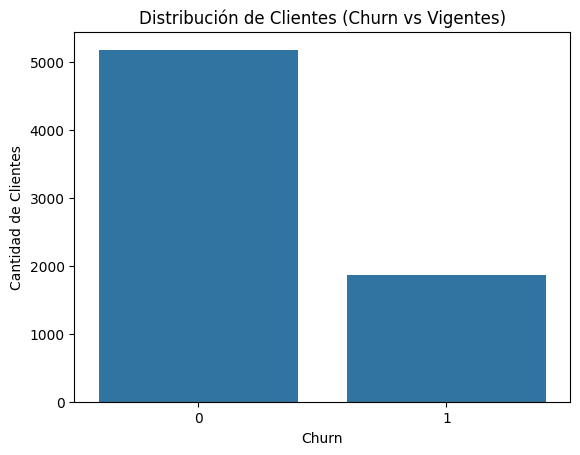

In [51]:
# se grafica el desbalance de clases con un grafico de barras
sns.countplot(x='churn', data=df_final)
plt.title('Distribución de Clientes (Churn vs Vigentes)')
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [52]:
# estadisticas descriptivas
df_final.describe()

,monthlycharges,totalcharges,churn,tenure_days,seniorcitizen
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,64.761692,2279.798992,0.265370,985.996166,0.162147
std,30.090047,2266.730170,0.441561,747.587844,0.368612
min,18.250000,18.800000,0.000000,0.000000,0.000000
25%,35.500000,398.550000,0.000000,273.000000,0.000000
50%,70.350000,1394.550000,0.000000,883.000000,0.000000
75%,89.850000,3786.600000,1.000000,1676.000000,0.000000
max,118.750000,8684.800000,1.000000,2191.000000,1.000000


Analizando las estadisticas descriptivas, encontramos que  la columna totalcharges, presenta valores maximos muy por encima del valor promedio, esto podria indicar que clientes presenten cancelacion por el alto valor en las tarifas de sus planes.

/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/3277206194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthlycharges', data=df_final, palette='magma')


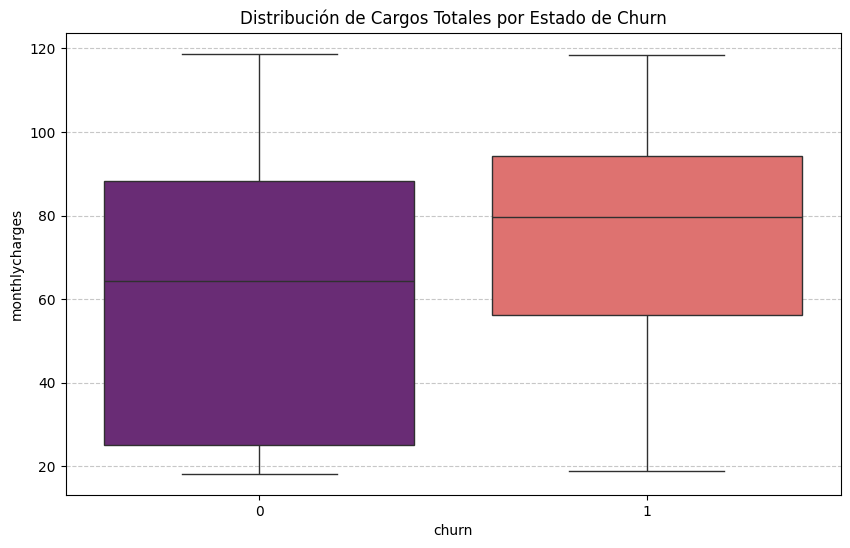

In [53]:
# se grafica un boxplot para identificar outliers en la columna monthlycharges
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='monthlycharges', data=df_final, palette='magma')
plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En el grafico de caja y bigotes se puede observar la distribucion de los cargos mensuales para los clientes que han cancelado (churn == 1) y los que no (churn == 0). Esto permite identificar si hay diferencias significativas en los cargos mensuales entre ambos grupos. Podemos observar que un 50% los clientes que cancelaron pagaban un valor valor mayor a los que estan vigentes. Podemos creer que el cargo mensual es un factor que determino la cancelacion del servicio por parte de los clientes. 


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_7532/2148037400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='totalcharges', data=df_final, palette='magma')


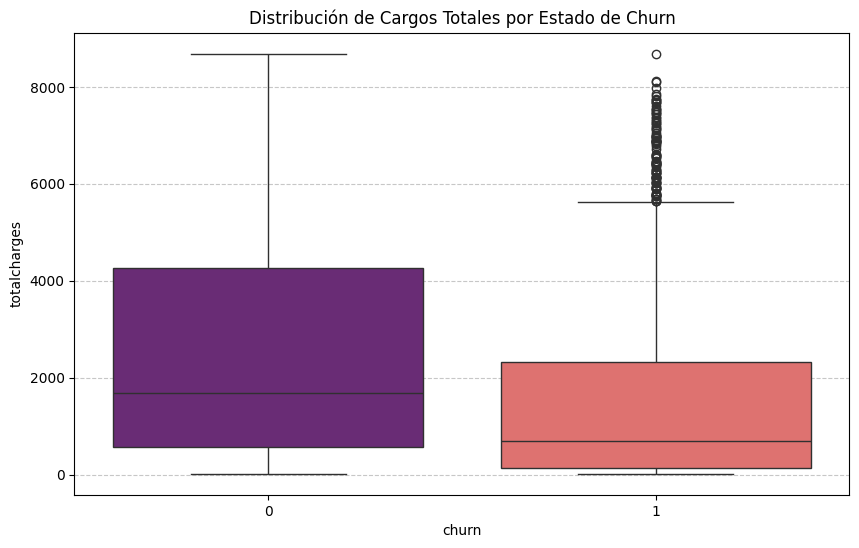

In [54]:
# se grafica un boxplot para identificar outliers en la columna totalcharges
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='totalcharges', data=df_final, palette='magma')
plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Entrando las estadisticas descriptivas, encontramos que  la columna totalcharges, presenta valores maximos muy por encima del valor promedio, esto podria indicar que clientes presenten cancelacion por el alto valor en las tarifas de sus planes. al igual hay valores atipicos de clientes que cancelaron con cargos superiores a los 5000.

In [55]:
df_final.query('churn == 1 and totalcharges > 5000 and tenure_days > 1000').head()

,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,gender,seniorcitizen,partner,dependents
13,0280-xjgex,month-to-month,yes,bank transfer (automatic),103.70,5036.30,1,1491,fiber optic,no,yes,yes,no,yes,yes,yes,male,0,no,no
104,3192-nqeca,two year,yes,bank transfer (automatic),110.00,7611.85,1,2071,fiber optic,no,yes,yes,yes,yes,yes,yes,male,0,yes,no
110,0486-heczi,month-to-month,yes,electronic check,96.75,5238.90,1,1675,fiber optic,yes,yes,no,no,yes,no,yes,male,0,yes,no
173,0691-jvsya,one year,yes,bank transfer (automatic),94.85,5000.20,1,1614,fiber optic,no,no,yes,no,yes,yes,no,female,0,yes,no
276,4484-glzou,month-to-month,yes,electronic check,105.05,5624.85,1,1583,fiber optic,no,yes,yes,no,yes,yes,yes,female,0,yes,no


In [56]:
df_final['type'].value_counts()

type
month-to-month    3875
two year          1695
one year          1473
Name: count, dtype: int64

In [57]:
df_final['onlinebackup'].value_counts()

onlinebackup
no         3088
yes        2429
unknown    1526
Name: count, dtype: int64

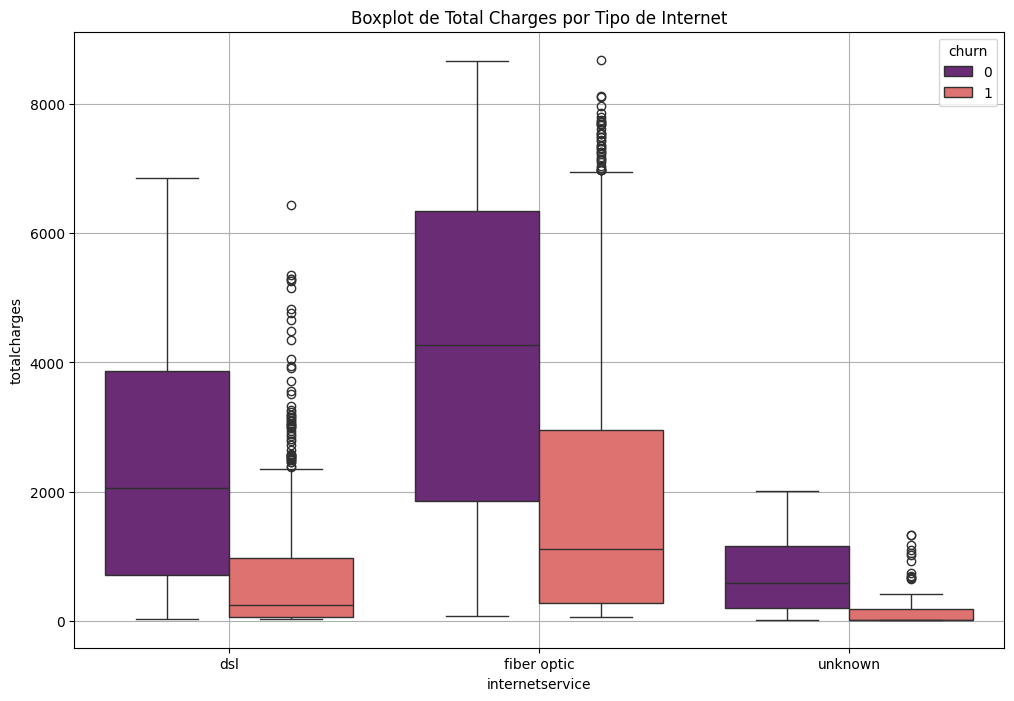

In [58]:
# grafico de caja y bigotes entre totalcharges e internetservice
plt.figure(figsize=(12, 8))
sns.boxplot(x='internetservice', y='totalcharges', data=df_final, hue='churn', palette='magma')
plt.title('Boxplot de Total Charges por Tipo de Internet')
plt.grid()
plt.show()


In [59]:
# Comparamos el promedio y la mediana de TotalCharges por tipo de internet
analisis_internet = df_final.groupby('internetservice')['totalcharges'].agg(['mean', 'median', 'std', 'max']).reset_index()
print(analisis_internet)

  internetservice         mean   median          std      max
0             dsl  2115.545456  1596.60  1880.542144  6859.05
1     fiber optic  3205.304570  2660.65  2570.220105  8684.80
2         unknown   662.690564   519.20   555.527036  2006.95


In [60]:
# analisis de churn vs tenure_days
churn_analysis = df_final.groupby('churn')['tenure_days'].agg(['mean', 'median', 'std', 'max']).reset_index()
print(churn_analysis)


   churn         mean  median         std   max
0      0  1144.447236  1157.0  733.897937  2191
1      1   547.352060   304.0  594.389607  2191


In [61]:
# analisis de churn, internetservice y totalcharges
churn_totalcharges_analysis = df_final.groupby(['churn', 'internetservice'])['totalcharges'].agg(['mean', 'median', 'std', 'max']).reset_index()
print(churn_totalcharges_analysis)


   churn internetservice         mean   median          std      max
0      0             dsl  2426.971993  2051.05  1885.246215  6859.05
1      0     fiber optic  4135.834074  4275.75  2506.756103  8672.45
2      0         unknown   701.778379   587.10   552.893724  2006.95
3      1             dsl   784.349673   239.55  1129.993971  6440.25
4      1     fiber optic  1914.616384  1111.65  2046.711293  8684.80
5      1         unknown   173.919912    21.00   296.409147  1334.00


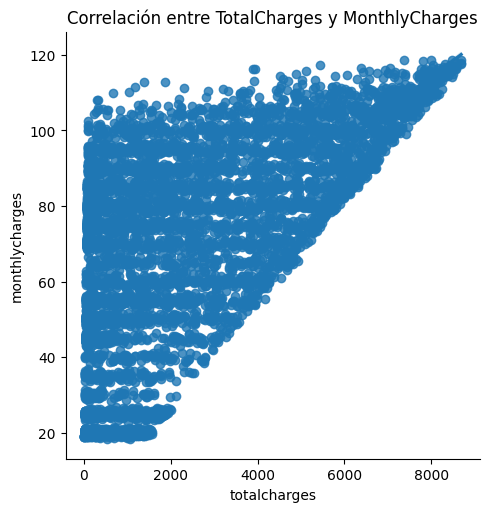

In [62]:
# grafico de correlacion entre totalcharges y monthlycharges
sns.lmplot(x='totalcharges', y='monthlycharges', data=df_final)
plt.title('Correlación entre TotalCharges y MonthlyCharges')
plt.show()




In [63]:
# correlacion entre totalcharges y monthlycharges
correlation_totalcharges_monthlycharges = df_final[['totalcharges', 'monthlycharges']].corr().iloc[0, 1]
print(f"Correlación entre TotalCharges y MonthlyCharges: {correlation_totalcharges_monthlycharges}")


Correlación entre TotalCharges y MonthlyCharges: 0.6511819850393806


Hemos identificado que la fibra optica aumenta el doble del total de cargos de los clientes, asi como clientes con un promedio mayor a 500 dias han cancelado su portafolio. podemos identificar que la matrix de cargos mensuales y totales tienen una correlacion positiva, elegimos usar para nuestro modelo solo la variable totalcharges para evitar multicolinealidad.  

# etapa de entrenamiento y modelado

In [64]:
# se definen las variables caracteristicas y objetivo
X = df_final.drop(columns=['churn','customerid','monthlycharges'])
y = df_final['churn']

In [65]:
# dividimos nuestro dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [66]:
X_train.shape

(4930, 17)

In [67]:
X_test.shape

(2113, 17)

In [68]:
y_train.shape

(4930,)

In [69]:
y_test.shape

(2113,)

In [70]:
X_train.head()

,type,paperlessbilling,paymentmethod,totalcharges,tenure_days,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,gender,seniorcitizen,partner,dependents
1695,one year,yes,electronic check,3770.00,1645,dsl,no,yes,no,yes,yes,no,yes,male,0,yes,yes
1095,month-to-month,yes,electronic check,80.55,31,fiber optic,no,no,no,no,yes,no,no,male,0,no,no
3889,one year,no,credit card (automatic),259.65,396,unknown,unknown,unknown,unknown,unknown,unknown,unknown,no,male,0,no,no
3667,two year,yes,electronic check,2263.45,730,fiber optic,no,no,yes,no,yes,yes,no,female,1,yes,yes
2902,month-to-month,yes,electronic check,450.90,184,fiber optic,yes,no,no,no,no,no,no,female,1,no,no


In [71]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 1695 to 860
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   type              4930 non-null   object 
 1   paperlessbilling  4930 non-null   object 
 2   paymentmethod     4930 non-null   object 
 3   totalcharges      4930 non-null   float64
 4   tenure_days       4930 non-null   int64  
 5   internetservice   4930 non-null   object 
 6   onlinesecurity    4930 non-null   object 
 7   onlinebackup      4930 non-null   object 
 8   deviceprotection  4930 non-null   object 
 9   techsupport       4930 non-null   object 
 10  streamingtv       4930 non-null   object 
 11  streamingmovies   4930 non-null   object 
 12  multiplelines     4930 non-null   object 
 13  gender            4930 non-null   object 
 14  seniorcitizen     4930 non-null   int64  
 15  partner           4930 non-null   object 
 16  dependents        4930 non-null   object 
dty

In [72]:
# se aplica one hot encoding a las variables categóricas
# se seleccionan las variables categóricas
categorical_features = X_train.select_dtypes(include=['object']).columns
categorical_features


Index(['type', 'paperlessbilling', 'paymentmethod', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'multiplelines', 'gender', 'partner',
       'dependents'],
      dtype='object')

In [73]:
# 1. se crea la instancia one hot encoder
ohe = OneHotEncoder(sparse_output=False)
# 2. se ajusta y transforma las variables categóricas en el conjunto de entrenamiento
X_train_encoded = ohe.fit_transform(X_train[categorical_features])

# 3. transformamos en conjunto de prueba
X_test_encoded = ohe.transform(X_test[categorical_features])

# 4. Recuperamos los nombres para crear un nuevo DataFrame
nombre_columnas = ohe.get_feature_names_out(categorical_features)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=nombre_columnas)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=nombre_columnas)


In [74]:
X_train_encoded_df.head()


,type_month-to-month,type_one year,type_two year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,internetservice_dsl,...,streamingmovies_yes,multiplelines_no,multiplelines_unknown,multiplelines_yes,gender_female,gender_male,partner_no,partner_yes,dependents_no,dependents_yes
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [75]:
X_train_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   type_month-to-month                      4930 non-null   float64
 1   type_one year                            4930 non-null   float64
 2   type_two year                            4930 non-null   float64
 3   paperlessbilling_no                      4930 non-null   float64
 4   paperlessbilling_yes                     4930 non-null   float64
 5   paymentmethod_bank transfer (automatic)  4930 non-null   float64
 6   paymentmethod_credit card (automatic)    4930 non-null   float64
 7   paymentmethod_electronic check           4930 non-null   float64
 8   paymentmethod_mailed check               4930 non-null   float64
 9   internetservice_dsl                      4930 non-null   float64
 10  internetservice_fiber optic              4930 no

In [76]:
X_test_encoded_df.head()

,type_month-to-month,type_one year,type_two year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,internetservice_dsl,...,streamingmovies_yes,multiplelines_no,multiplelines_unknown,multiplelines_yes,gender_female,gender_male,partner_no,partner_yes,dependents_no,dependents_yes
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [77]:
X_test_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   type_month-to-month                      2113 non-null   float64
 1   type_one year                            2113 non-null   float64
 2   type_two year                            2113 non-null   float64
 3   paperlessbilling_no                      2113 non-null   float64
 4   paperlessbilling_yes                     2113 non-null   float64
 5   paymentmethod_bank transfer (automatic)  2113 non-null   float64
 6   paymentmethod_credit card (automatic)    2113 non-null   float64
 7   paymentmethod_electronic check           2113 non-null   float64
 8   paymentmethod_mailed check               2113 non-null   float64
 9   internetservice_dsl                      2113 non-null   float64
 10  internetservice_fiber optic              2113 no

In [78]:
# se seleccionan las variables numericas
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
numerical_features


Index(['totalcharges', 'tenure_days', 'seniorcitizen'], dtype='object')

In [79]:
# Concatenamos las numéricas originales con las nuevas categóricas
X_train_final = pd.concat([X_train[numerical_features].reset_index(drop=True), X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test[numerical_features].reset_index(drop=True), X_test_encoded_df], axis=1)

In [80]:
# se comprueba si hay valores nulos en el conjunto de entrenamiento
X_train_final.isna().sum()

totalcharges                               0
tenure_days                                0
seniorcitizen                              0
type_month-to-month                        0
type_one year                              0
type_two year                              0
paperlessbilling_no                        0
paperlessbilling_yes                       0
paymentmethod_bank transfer (automatic)    0
paymentmethod_credit card (automatic)      0
paymentmethod_electronic check             0
paymentmethod_mailed check                 0
internetservice_dsl                        0
internetservice_fiber optic                0
internetservice_unknown                    0
onlinesecurity_no                          0
onlinesecurity_unknown                     0
onlinesecurity_yes                         0
onlinebackup_no                            0
onlinebackup_unknown                       0
onlinebackup_yes                           0
deviceprotection_no                        0
deviceprot

In [81]:
# se comprueba si hay valores nulos en el conjunto de prueba
X_test_final.isna().sum()

totalcharges                               0
tenure_days                                0
seniorcitizen                              0
type_month-to-month                        0
type_one year                              0
type_two year                              0
paperlessbilling_no                        0
paperlessbilling_yes                       0
paymentmethod_bank transfer (automatic)    0
paymentmethod_credit card (automatic)      0
paymentmethod_electronic check             0
paymentmethod_mailed check                 0
internetservice_dsl                        0
internetservice_fiber optic                0
internetservice_unknown                    0
onlinesecurity_no                          0
onlinesecurity_unknown                     0
onlinesecurity_yes                         0
onlinebackup_no                            0
onlinebackup_unknown                       0
onlinebackup_yes                           0
deviceprotection_no                        0
deviceprot

In [82]:
# aplicamos standard scaler a las variables numericas
scaler = StandardScaler()


In [83]:
# 1. ajustamos y entrenamos solo las columnas numericas en entrenamiento
X_train_final[numerical_features] = scaler.fit_transform(X_train_final[numerical_features])

# 2. aplicamos la misma transformación a las columnas numericas en el conjunto de prueba
X_test_final[numerical_features] = scaler.transform(X_test_final[numerical_features])


# MODELO DE REGRESION LOGISTICA

Este modelo nos sirve como baseline, para determinar el punto de partida al momento de entrenar modelos mas avanzados, buscando eficiencia y simplitud a la hora de predecir los clientes con probabilidad de fuga. 

Nuestro modelo presenta un desbalance en la variable objetivo, un 76% corresponde a clientes que estan vigentes con la empresa, con lo que corremos el riesgo que el modelo prediga que un cliente no se va a ir. Para una mayor confianza en nuestro modelo de regresion aplicamos el parametro de weight_class para dar mayor peso a la clase minoritaria, este con el fin de mejorar la precision en las predicciones. 

In [84]:
# Aplicamos parametro weight_class dentro del modelo de regresion logistica
# 1. creamos la instancia del modelo de regresion logistica
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

In [85]:
# 2. Entrenamos el modelo de regresion logistica
log_reg.fit(X_train_final, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [86]:
# 3.realizamos predicciones en el set de prueba
y_pred = log_reg.predict(X_test_final)


In [87]:
# 4. Evaluamos el rendimiento del modelo
print('reporte de clasificacion')
print(classification_report(y_test, y_pred))

reporte de clasificacion
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1539
           1       0.53      0.84      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.82      0.76      0.77      2113



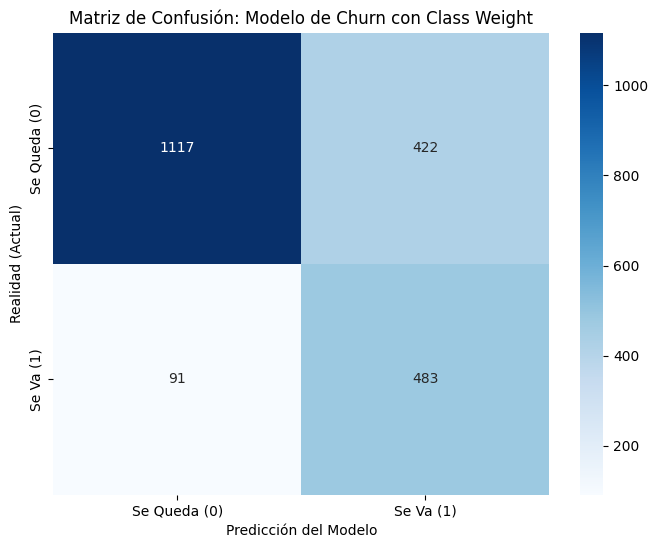

In [88]:
# calculamos matriz de confusion
# 1. Calculamos la matriz
cm = confusion_matrix(y_test, y_pred)

# 2. La visualizamos con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión: Modelo de Churn con Class Weight')
plt.show()

# MODELO AUC-ROC REGRESION LOGISTICA


In [89]:
# calculamos modelo auc-roc
# calculamos la probabilidad de la clase 1 (churn)
y_proba = log_reg.predict_proba(X_test_final)[:, 1]

# 2. Calculamos el puntaje AUC
auc_rl = roc_auc_score(y_test, y_proba)
print(f"El AUC-ROC de mi modelo es: {auc_rl:.3f}")



El AUC-ROC de mi modelo es: 0.859


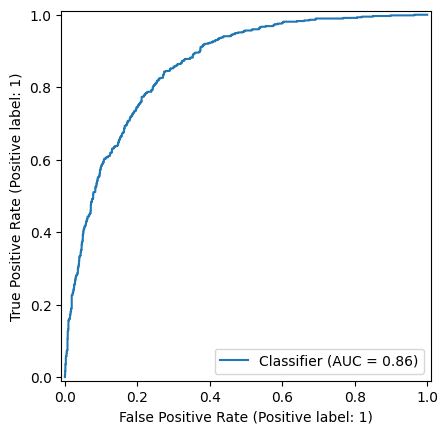

In [90]:
# # 3. Graficamos la curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba)


#  MODELO DE RANDOM FOREST

In [91]:
# Creamos instancia del modelo de Random Forest
random_forest = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

In [92]:
# entrenamos modelo de random forest
random_forest.fit(X_train_final, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
# realizamos predicciones en el set de prueba
y_pred_random_forest = random_forest.predict(X_test_final)

In [94]:
# evaluamos el modelo
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1539
           1       0.69      0.49      0.57       574

    accuracy                           0.80      2113
   macro avg       0.76      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



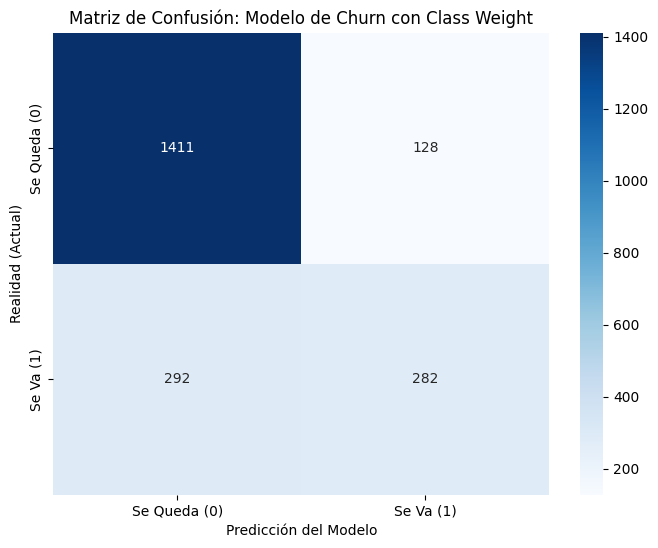

In [95]:
# calculamos matriz de confusión
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)

# 2. La visualizamos con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_random_forest, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión: Modelo de Churn con Class Weight')
plt.show()


# MODELO AUC-ROC RANDOM FOREST


In [96]:
# calculamos modelo auc-roc
# calculamos la probabilidad de la clase 1 (churn)
y_proba_random_forest = random_forest.predict_proba(X_test_final)[:, 1]

# 2. Calculamos el puntaje AUC
auc_rf = roc_auc_score(y_test, y_proba_random_forest)
print(f"El AUC-ROC de mi modelo es: {auc_rf:.3f}")

El AUC-ROC de mi modelo es: 0.843


Text(0.5, 1.0, 'Curva ROC: Modelo de Churn con Class Weight')

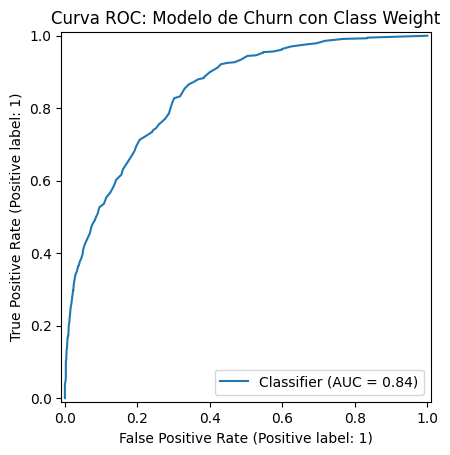

In [97]:
# # 3. Graficamos la curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_random_forest)
plt.title('Curva ROC: Modelo de Churn con Class Weight')

# MODELO CATBOOST

In [98]:
# Se crea instancia modelo catboost
modelo_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced', 
    random_seed=42,
    verbose=100 
)

In [99]:
# entrenamiento del modelo catboost
modelo_cat.fit(X_train_final, y_train)

0:	learn: 0.6723851	total: 61.7ms	remaining: 1m 1s
100:	learn: 0.4173391	total: 186ms	remaining: 1.65s
200:	learn: 0.3637508	total: 314ms	remaining: 1.25s
300:	learn: 0.3200540	total: 444ms	remaining: 1.03s
400:	learn: 0.2860920	total: 573ms	remaining: 856ms
500:	learn: 0.2579044	total: 704ms	remaining: 701ms
600:	learn: 0.2354467	total: 835ms	remaining: 554ms
700:	learn: 0.2163057	total: 963ms	remaining: 411ms
800:	learn: 0.2002401	total: 1.09s	remaining: 272ms
900:	learn: 0.1870189	total: 1.22s	remaining: 135ms
999:	learn: 0.1751255	total: 1.35s	remaining: 0us


In [100]:
# predicciones del modelo catboost
y_pred_cat = modelo_cat.predict(X_test_final)

In [101]:
# evaluación del modelo catboost
print(classification_report(y_test, y_pred_cat))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1539
           1       0.74      0.81      0.78       574

    accuracy                           0.87      2113
   macro avg       0.84      0.85      0.84      2113
weighted avg       0.88      0.87      0.87      2113



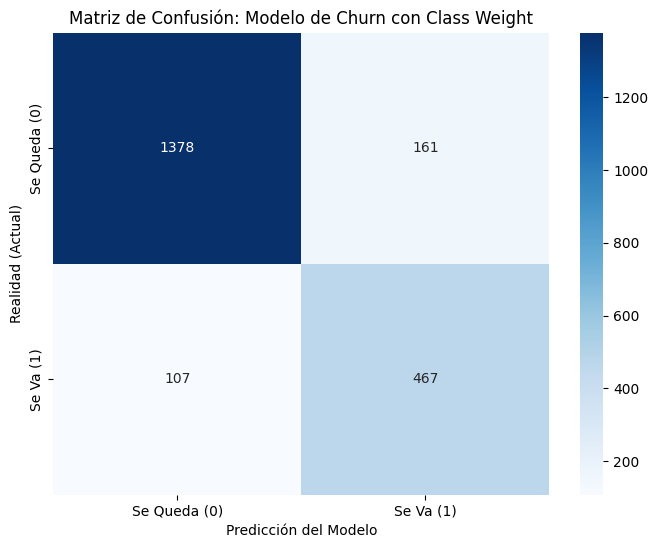

In [102]:
# calculamos matriz de confusión
cm_catboost = confusion_matrix(y_test, y_pred_cat)

# 2. La visualizamos con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión: Modelo de Churn con Class Weight')
plt.show()


# Modelo AUC-ROC CATBOOST

In [103]:
# calculamos modelo auc-roc
# calculamos la probabilidad de la clase 1 (churn)
y_proba_catboost = modelo_cat.predict_proba(X_test_final)[:, 1]

# 2. Calculamos el puntaje AUC
auc_ct = roc_auc_score(y_test, y_proba_catboost)
print(f"El AUC-ROC de mi modelo es: {auc_ct:.3f}")

El AUC-ROC de mi modelo es: 0.931


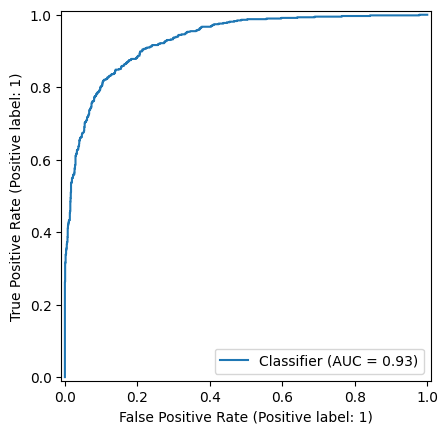

In [104]:
# # 3. Graficamos la curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_catboost)

# MODELO LIGHTGBM

In [105]:
# 1. Se crea instancia del modelo
modelo_lgb = lgb.LGBMClassifier(
    is_unbalance=True,  
    random_state=42,
    learning_rate=0.05,
    n_estimators=1000
)

In [106]:
# 2. se entrena el modelo 
modelo_lgb.fit(X_train_final, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1295, number of negative: 3635
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 476
[LightGBM] [Info] Number of data points in the train set: 4930, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.262677 -> initscore=-1.032098
[LightGBM] [Info] Start training from score -1.032098


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [107]:
# 3. se realiza la predicción
y_pred_lightgbm = modelo_lgb.predict(X_test_final)

In [108]:
# 4. se evalua el modelo
print(classification_report(y_test, y_pred_lightgbm))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1539
           1       0.74      0.72      0.73       574

    accuracy                           0.86      2113
   macro avg       0.82      0.81      0.81      2113
weighted avg       0.85      0.86      0.85      2113



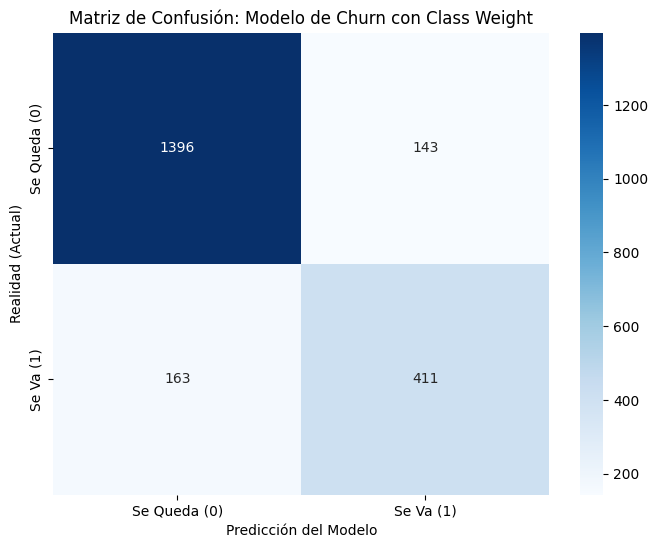

In [109]:
# matriz de confusión
cm_lightgbm = confusion_matrix(y_test, y_pred_lightgbm)

# 2. La visualizamos con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lightgbm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión: Modelo de Churn con Class Weight')
plt.show()


# Modelo AUC-ROC LIGHTGBM

In [110]:
# calculamos modelo auc-roc
# calculamos la probabilidad de la clase 1 (churn)
y_proba_lightgbm = modelo_lgb.predict_proba(X_test_final)[:, 1]

# 2. Calculamos el puntaje AUC
auc_lb = roc_auc_score(y_test, y_proba_lightgbm)
print(f"El AUC-ROC de mi modelo es: {auc_lb:.3f}")

El AUC-ROC de mi modelo es: 0.917


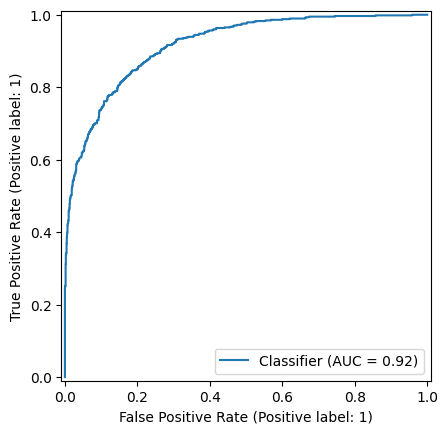

In [111]:
# Graficamos la curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_lightgbm)

# FUNCION DE EVALUACION DEL MODELO

Se define la funcion para la evaluacion del modelo. Aqui definiremos cual modelo se ajusta mejor a nuestro objetivo. 


In [124]:
# definimos la funcion de evaluacion del modelo
# regresion logistica
def evaluacion_modelo(y_test, y_pred, auc_rl):
    print(f'El AUC-ROC de la regresion logistica es: {auc_rl:.3f}')
    print('las principales metricas de la regresion logistica son:')
    print(f'{classification_report(y_test, y_pred)}')

    


In [125]:
# evaluacion modelo regresion logistica
evaluacion_modelo(y_test, y_pred, auc_rl)

El AUC-ROC de la regresion logistica es: 0.859
las principales metricas de la regresion logistica son:
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1539
           1       0.53      0.84      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.82      0.76      0.77      2113



In [126]:
# evaluacion modelo random forest
evaluacion_modelo(y_test, y_pred_random_forest, auc_rf)

El AUC-ROC de la regresion logistica es: 0.843
las principales metricas de la regresion logistica son:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1539
           1       0.69      0.49      0.57       574

    accuracy                           0.80      2113
   macro avg       0.76      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



In [127]:
# evaluacion modelo catboost
evaluacion_modelo(y_test, y_pred_cat, auc_ct)

El AUC-ROC de la regresion logistica es: 0.931
las principales metricas de la regresion logistica son:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1539
           1       0.74      0.81      0.78       574

    accuracy                           0.87      2113
   macro avg       0.84      0.85      0.84      2113
weighted avg       0.88      0.87      0.87      2113



In [128]:
# evaluacion modelo lightgbm
evaluacion_modelo(y_test, y_pred_lightgbm, auc_lb)

El AUC-ROC de la regresion logistica es: 0.917
las principales metricas de la regresion logistica son:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1539
           1       0.74      0.72      0.73       574

    accuracy                           0.86      2113
   macro avg       0.82      0.81      0.81      2113
weighted avg       0.85      0.86      0.85      2113



# MODELO FINAL


In [117]:
test_results = X_test_final.copy()
test_results['Probabilidad_Churn'] = modelo_cat.predict_proba(X_test_final)[:, 1]
test_results['Prediccion_Final'] = modelo_cat.predict(X_test_final)

# Ordenamos por los que tienen más riesgo
top_riesgo = test_results.sort_values(by='Probabilidad_Churn', ascending=False)
print(top_riesgo[['Probabilidad_Churn', 'Prediccion_Final']].sample(20))

      Probabilidad_Churn  Prediccion_Final
2012            0.005406                 0
364             0.008155                 0
1373            0.906239                 1
1797            0.988162                 1
2087            0.160535                 0
976             0.035156                 0
1319            0.007480                 0
1298            0.997637                 1
1816            0.003580                 0
796             0.021764                 0
2008            0.025346                 0
1536            0.412813                 0
1344            0.039635                 0
128             0.001302                 0
902             0.004048                 0
1522            0.027067                 0
514             0.002232                 0
561             0.048179                 0
1532            0.321126                 0
1321            0.003558                 0


# CONCLUSIONES FINALES

## 1. Estrategia de Balanceo de Clases

Para abordar el desbalance de clases (26% minoritaria vs. 74% mayoritaria), se optó por el ajuste de hiperparámetros nativos de los modelos (como scale_pos_weight y auto_class_weights) en lugar de técnicas de sobremuestreo sintético. Esta decisión estratégica previene el overfitting y garantiza que el modelo aprenda de patrones reales, manteniendo la integridad de la distribución original de los datos. 

## 2. Tratamiento de Valores Faltantes (Unknowns)

Para abordar el desbalance de clases (26% minoritaria vs. 74% mayoritaria), se optó por el ajuste de hiperparámetros nativos de los modelos (como scale_pos_weight y auto_class_weights) en lugar de técnicas de sobremuestreo sintético. Esta decisión estratégica previene el overfitting y garantiza que el modelo aprenda de patrones reales, manteniendo la integridad de la distribución original de los datos. 

## 3. Ingeniería de Características (Feature Engineering)

El proceso de Feature Engineering, específicamente la creación de la variable 'Antigüedad en días', resultó determinante para el rendimiento del modelo. El análisis reveló patrones críticos de abandono en clientes con cargos totales superiores a 5,000 y una permanencia mayor a 1,000 días, lo que sugiere un punto de fricción en la lealtad a largo plazo que el modelo logró capturar con éxito.

## 4. Selección del Modelo Ganador

Se seleccionó CatBoost como el modelo productivo debido a su robustez y superioridad en las métricas de evaluación. El modelo destaca no solo por su AUC-ROC, que valida su capacidad para jerarquizar el riesgo de los clientes, sino también por su F1-Score, que garantiza un equilibrio óptimo entre la precisión de las alertas y la cobertura de detección

## 5. Impacto Operativo (Recall)

Nuestro modelo tiene una sensibilidad (Recall) del 81%. Esto significa que somos capaces de detectar a 8 de cada 10 clientes que están a punto de abandonar el portafolio antes de que lo hagan, permitiéndonos actuar a tiempo con estrategias de retención.